In [81]:
import numpy as np
import torch

from frame import Frame
from pfn import PFNLayer
from pillarisation import assign_pillars, augment_pillars, create_pillars, crop


In [82]:
DEFAULT_PATH_IMG = '../data/data_object_image_2/training/image_2/'
DEFAULT_PATH_LIDAR = '../data/data_object_velodyne/training/velodyne/'
DEFAULT_PATH_CALIB = '../data/data_object_calib/training/calib/'
DEFAULT_PATH_LABEL = '../data/data_object_label_2/training/label_2/'

In [83]:
frame = Frame('000006', DEFAULT_PATH_IMG, DEFAULT_PATH_LIDAR, DEFAULT_PATH_CALIB, DEFAULT_PATH_LABEL)
frame.load_lidar()

raw_lidar = frame.raw_lidar
print(f'Raw LIDAR Points: {raw_lidar.shape[0]}')

Raw LIDAR Points: 110089


In [84]:
x_min, x_max = 0.0, 69.12
y_min, y_max = -39.68, 39.68
z_min, z_max = -3.0, 1.0

cropped_lidar = crop(raw_lidar, x_min, x_max, y_min, y_max, z_min, z_max)
print(f'Cropped LIDAR Points: {cropped_lidar.shape[0]}')

Cropped LIDAR Points: 53215


In [85]:
delta_x, delta_y = 0.16, 0.16 # pillar (ie. cell) dimensions
N_x, N_y = int((x_max-x_min)/delta_x), int((y_max-y_min)/delta_y)
print(f'No. of pillars (N_x, N_y): {(N_x, N_y)}')

No. of pillars (N_x, N_y): (432, 496)


In [86]:
indexed_lidar = assign_pillars(cropped_lidar, x_min, delta_x, y_min, delta_y)

In [87]:
pillars = create_pillars(indexed_lidar, N_x, N_y, Np_max=32)
print(pillars.shape)

(496, 432, 32, 4)


In [88]:
non_empty_mask = np.any(pillars != 0, axis=(2, 3))
print(f'No. of non-empty pillars: P = {non_empty_mask.sum()}')

# keep only non-empty pillars + save their coordinates
non_empty = pillars[non_empty_mask]
non_empty_coords = np.argwhere(non_empty_mask)

No. of non-empty pillars: P = 11946


In [89]:
augmented_pillars = augment_pillars(pillars=non_empty,
                                    pillar_coords=non_empty_coords,
                                    x_min=x_min, delta_x=delta_x,
                                    y_min=y_min, delta_y=delta_y)

print(f'Augmented pillars tensor: {augmented_pillars.shape}')

Augmented pillars tensor: (11946, 32, 9)


In [90]:
pfn = PFNLayer(in_channels=9, out_channels=64)
features = pfn(torch.from_numpy(augmented_pillars).to(dtype=torch.float32))

print(f'Pillars feature tensor: {features.shape}')

Pillars feature tensor: torch.Size([11946, 64])


__Plotting Individual PFN Channel Outputs__

In [91]:
bev = torch.zeros(64, N_y, N_x)

for p in range(features.shape[0]):
    y, x = non_empty_coords[p]

    bev[:, y, x] = features[p]

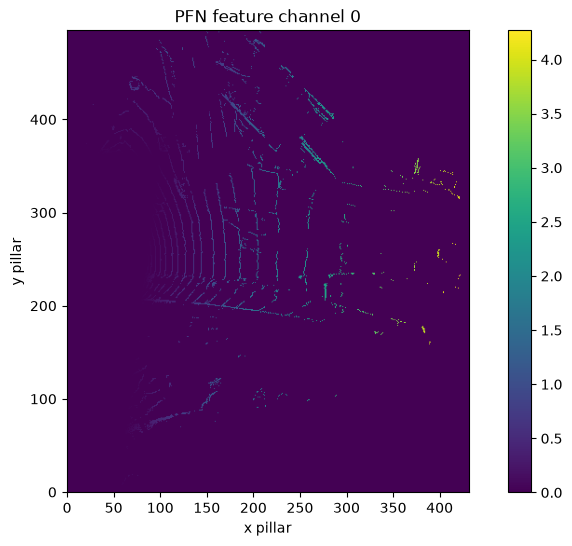

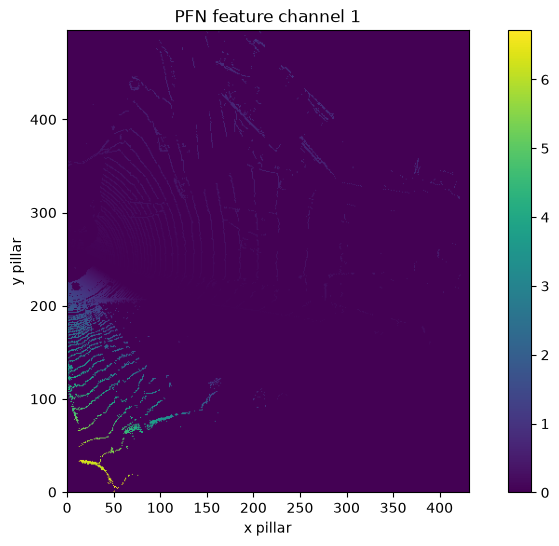

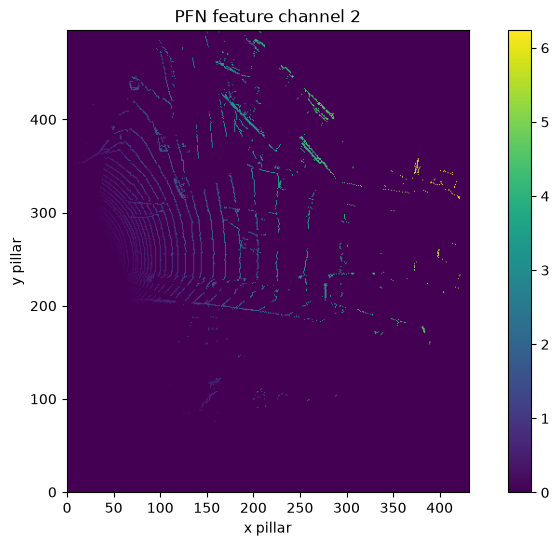

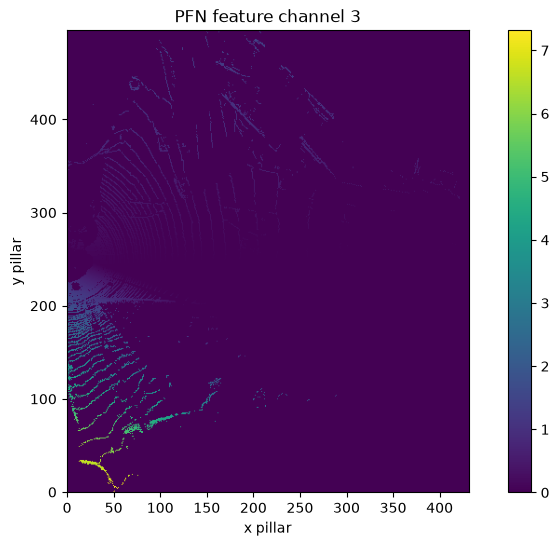

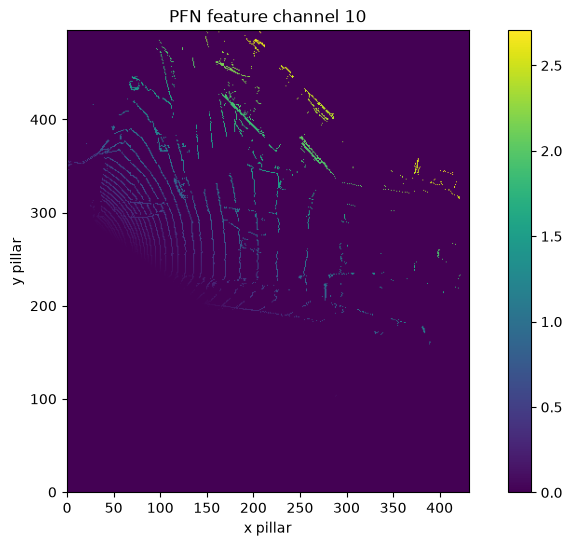

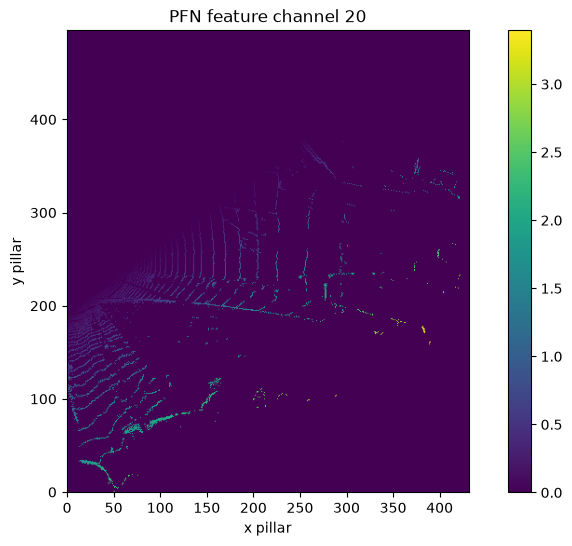

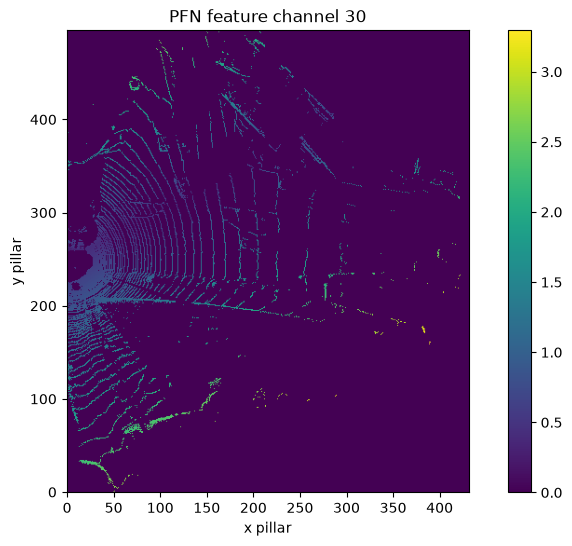

In [92]:
import matplotlib.pyplot as plt

for channel in [0, 1, 2, 3, 10, 20, 30]:

    plt.figure(figsize=(10, 6))

    plt.imshow(
        bev[channel].detach().cpu().numpy(),
        origin="lower"
    )

    plt.title(f"PFN feature channel {channel}")
    plt.xlabel("x pillar")
    plt.ylabel("y pillar")
    plt.colorbar()

    plt.show()

__Plotting Feature Magnitudes__

In [93]:
feature_magnitude = torch.norm(bev, dim=0)
print(feature_magnitude.shape)

torch.Size([496, 432])


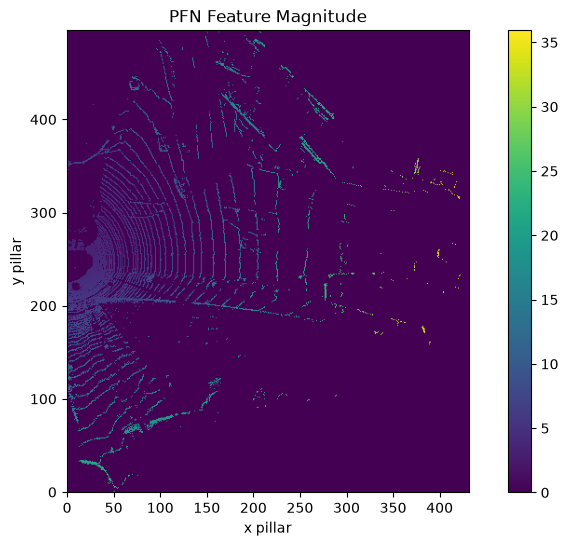

In [94]:
plt.figure(figsize=(10, 6))

plt.imshow(feature_magnitude.detach().cpu().numpy(), origin="lower")

plt.title("PFN Feature Magnitude")
plt.xlabel("x pillar")
plt.ylabel("y pillar")
plt.colorbar()

plt.show()